In [1]:
%matplotlib inline

# Module 12 - Programming Assignment

## Directions

1. Change the name of this file to be your JHED id as in `jsmith299.ipynb`. Because sure you use your JHED ID (it's made out of your name and not your student id which is just letters and numbers).
2. Make sure the notebook you submit is cleanly and fully executed. I do not grade unexecuted notebooks.
3. Submit your notebook back in Blackboard where you downloaded this file.

*Provide the output **exactly** as requested*

# The Problem

When we last left our agent in Modules 1 and 11, it was wandering around a world filled with plains, forests, swamps, hills and mountains. This presupposes a map with known terrain:

```
......
...**.
...***
..^...
..~^..
```

but what if all we know is that we have some area of interest, that we've reduced to a GPS grid:

```
??????
??????
??????
??????
??????
```

and the agent has to determine what kind of terrain is to the left, front and right of it?

Assuming the agent has a very simple visual sensor that constructs a 4x4 grayscale image for each of the three directions, it might it could see something like this:

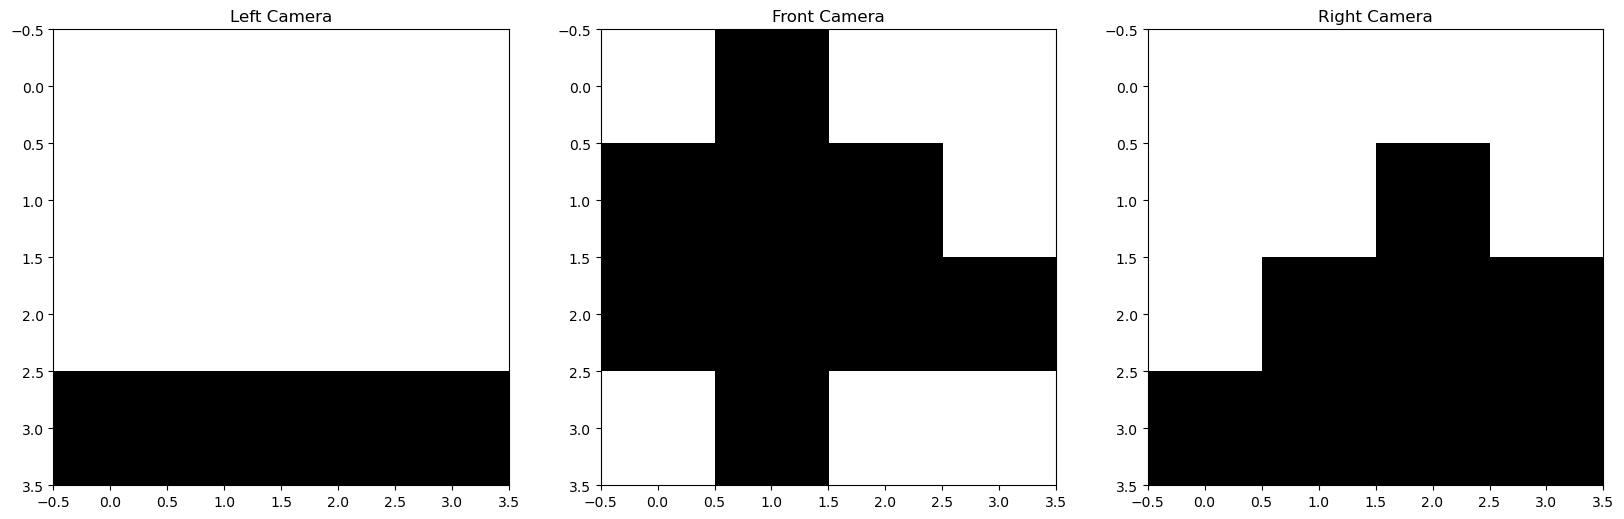

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import random

plain =  [0.0, 0.0, 0.0, 0.0,0.0, 0.0, 0.0, 0.0,0.0, 0.0, 0.0, 0.0,1.0, 1.0, 1.0, 1.0]
forest = [0.0, 1.0, 0.0, 0.0,1.0, 1.0, 1.0, 0.0,1.0, 1.0, 1.0, 1.0,0.0, 1.0, 0.0, 0.0]
hills =  [0.0, 0.0, 0.0, 0.0,0.0, 0.0, 1.0, 0.0,0.0, 1.0, 1.0, 1.0,1.0, 1.0, 1.0, 1.0]
swamp =  [0.0, 0.0, 0.0, 0.0,0.0, 0.0, 0.0, 0.0,1.0, 0.0, 1.0, 0.0,1.0, 1.0, 1.0, 1.0]

figure = plt.figure(figsize=(20,6))

axes = figure.add_subplot(1, 3, 1)
pixels = np.array([255 - p * 255 for p in plain], dtype='uint8')
pixels = pixels.reshape((4, 4))
axes.set_title( "Left Camera")
axes.imshow(pixels, cmap='gray')

axes = figure.add_subplot(1, 3, 2)
pixels = np.array([255 - p * 255 for p in forest], dtype='uint8')
pixels = pixels.reshape((4, 4))
axes.set_title( "Front Camera")
axes.imshow(pixels, cmap='gray')

axes = figure.add_subplot(1, 3, 3)
pixels = np.array([255 - p * 255 for p in hills], dtype='uint8')
pixels = pixels.reshape((4, 4))
axes.set_title( "Right Camera")
axes.imshow(pixels, cmap='gray')

plt.show()
plt.close()

which would be plains, forest and hills respectively.

## The Assignment

For this programming assignment your tasks are:

1. Write a logistic regression that simply determines if something is a hill or not (two class problem). 
2. You will also evaluate that logistic regression by generating a *confusion matrix*.

For a starting point, refer to the Pseudocode and the Self-Check.

## Data

We have clean examples of the different types of terrain but based on the location, the registration can be a bit off for some of the types and the visual sensor is often noisy.

Here are the clean examples with different registrations: 

In [3]:
clean_data = {
    "plains": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, "plains"]
    ],
    "forest": [
        [0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, "forest"],
        [0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.0, 0.0, 1.0, 0.0, "forest"],
        [1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 0.0, 0.0, 0.0, "forest"],
        [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 0.0, 0.0, 0.0, 1.0, "forest"]
    ],
    "hills": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 1.0, 0.0, 0.0, 1.0, 1.0, 1.0, 0.0, "hills"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, 1.0, 0.0, 1.0, 1.0, 1.0, "hills"]
    ],
    "swamp": [
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, "swamp"],
        [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0, 1.0, 1.0, 1.0, 1.0, 1.0, "swamp"]        
    ]
}

Let's create a function that allows us to view any of these:

In [4]:
def view_sensor_image(data):
    figure = plt.figure(figsize=(4,4))
    axes = figure.add_subplot(1, 1, 1)
    pixels = np.array([255 - p * 255 for p in data[:-1]], dtype='uint8')
    pixels = pixels.reshape((4, 4))
    axes.set_title( "Left Camera:" + data[-1])
    axes.imshow(pixels, cmap='gray')
    plt.show()
    plt.close()

"I think that I shall never see a thing so lovely as a tree."

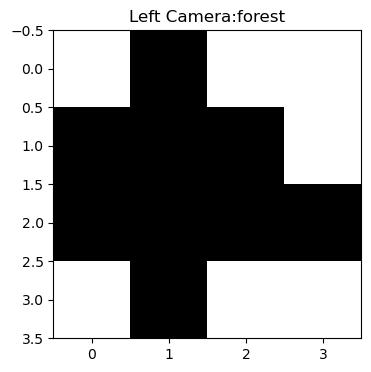

In [5]:
view_sensor_image( clean_data[ "forest"][0])

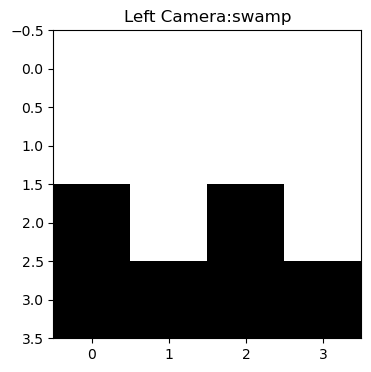

In [6]:
view_sensor_image( clean_data["swamp"][0])

The data that comes in, however, is noisy. The values are never exactly 0 and 1. In order to mimic this we need a `blur` function.

We will assume that noise is normally distributed. For values that should be 0, the noisy values are distributed $N(0.10, 0.05)$. For values should be 1, the noisy values are distributed $N(0.9, 0.10)$.

In [7]:
def blur( data):
    def apply_noise( value):
        if value < 0.5:
            v = random.gauss( 0.10, 0.05)
            if v < 0.0:
                return 0.0
            if v > 0.75:
                return 0.75
            return v
        else:
            v = random.gauss( 0.90, 0.10)
            if v < 0.25:
                return 0.25
            if v > 1.00:
                return 1.00
            return v
    noisy_readings = [apply_noise( v) for v in data[0:-1]]
    return noisy_readings + [data[-1]]

We can see how this affects what the agent *actually* sees.

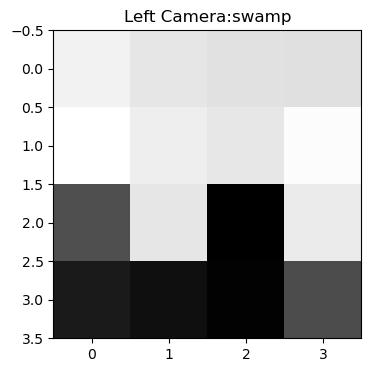

In [8]:
view_sensor_image( blur( clean_data["swamp"][0]))

We need four (4) functions:

1. `generate_data`
2. `learn_model`
3. `apply_model`
4. `evaluate`

### generate_data

`generate_data` has been written for you.

* clean_data - the clean versions of the "bitmaps" for each of the terrain types
* n - the number of samples for "in the class" (1) and "not in the class" (0) to generate.
* label - the label to chose as "in the class".

For example,

`generate_data( clean_data, 100, "hills")`

generates 100 hills, 100 not hills and has transformed the String labels into 1 and 0, respectively.

### `learn_model`

`learn_model` is the function that takes in training data and actually learns the logistic regression model. If you're up to it, you can implement a vectorized version using Numpy but you might start with the loopy version first.

*In the lecture, I mentioned that you usually should mean normalize your data but you don't need to do that in this case because the data is already on the range 0-1.*

I should also mention that gradient descent is not the usual approach to linear regression because the error function actually has an *exact* solution. However, in the case of large data sets, the exact solution often fails and in any case, the use of gradient descent will prepare you for neural networks next week.

When verbose is True, you should print out the error so you can see that it is getting smaller. 

When developing your algorithm, you need to watch the error so you'll set verbose=True to start. You should print it out every iteration and make sure it is declining. You'll have to experiment with both epsilon and alpha; and it doesn't hurt to make alpha adaptive (if the error increases, make alpha = alpha / 10).

When you know that your algorithm is working, change your code so that the error is printed out only every 1,000 iterations (it takes a lot of iterations for this problem to converge, depending on your parameter values--start early).

`learn_model` returns the List of Thetas.

### `apply_model`

`apply_model` takes a List of Thetas (the model) and either labeled or unlabeled data. If the data is unlabeled, it will return predictions for each observation as a Tuple of the inferred value (0 or 1) and the actual probability (so something like (1, 0.73) or (0, 0.29). We always return the class with the higher probability.

If the data are labeled, you will return a Tuple of the actual value (0 or 1) and the predicted value (0 or 1). In this case, you return a List of something like [(0, 1), (1, 1), (0, 0), (1, 0)].

### `evaluate`

Ideally, we should be running 10 fold cross validation on this problem but...that might take a while so we're going to just go ahead with a simple evaluation. We're interested not only in the error rate but the overall "confusion" of the model.

The `evaluate` takes the results of `apply_model` when labeled=True and prints out the error rate and a confusion matrix.

---

Why `labeled=True` or `labeled=False`? While we only have labeled data right now, for model evaluation. In the future, you would need to use this function to do actual classification. In that case, `labeled=False`. Because in the long run, that's the default usage, we use `False` as the default.

---

**As always when working with Lists or Lists of Lists, be very careful when you are modifying these items in place that this is what you want.**

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import random

<a id="sigmoid"></a>
## sigmoid

This function calculates the logistic sigmoid of a given input, z, which is used in logistic regression to transform linear predictions to probabilities (ranging between 0 and 1). The sigmoid function is fundamental in binary classification tasks as it maps any real-valued number into the (0, 1) interval, effectively enabling a decision to be made based on probability thresholds. The sigmoid function is the following: 

$$ \hat{y} = \frac{1}{1+e^{-z}} $$

* **z** float: variable in the sigmoid function
  
**returns** **logistic sigmoid** float: calculated logistic sigmoid

In [10]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [11]:
assert np.isclose(sigmoid(0), 0.5)

assert np.isclose(sigmoid(10), 1, atol=1e-3)

assert np.isclose(sigmoid(-10), 0, atol=1e-3)

<a id="derivative"></a>
## derivative

This function calculates the gradient of the error with respect to a particular parameter $ \theta_j $ (where j indexes the parameter). The gradient is used in gradient descent to adjust the parameters of the model. The function takes a slice of the dataset for the feature indexed by j, computes the prediction errors, and then determines the gradient. These gradients indicate the direction and magnitude by which the parameter $ \theta_j $ should be adjusted to minimize the error. The derivative calculates the following:

$$ \frac{\partial J}{\partial \theta_j} = \frac{1}{n}\sum_i(\hat{y_i} - y_i)x_{ij} $$

* **j** int: index of the parameter in query
* **thetas** list: list of parameters
* **data** np.array: array of data points
  
**returns** **gradient** float: calculated gradient

In [12]:
def derivative(j, thetas, data):
    X = np.array([x for x, _ in data])
    y = np.array([y for _, y in data])
    predictions = sigmoid(np.dot(X, thetas))
    errors = y - predictions
    gradient = -np.dot(X[:, j], errors) / len(X)  # Negative sign for gradient ascent
    return gradient

In [13]:
X_test = np.array([[1, 1, 1], [1, 2, 1], [2, 1, 2]])  # 3 samples, 2 features
y_test = np.array([0, 1, 1])  # Binary labels
data_test = list(zip(X_test, y_test))
theta_test = np.array([0.1, -0.2, 0.1])

calculated_derivative_0 = derivative(0, theta_test, data_test)
assert -0.32 < calculated_derivative_0 < -0.31

calculated_derivative_1 = derivative(1, theta_test, data_test)
assert -0.35 < calculated_derivative_1 < -0.34

calculated_derivative_2 = derivative(2, theta_test, data_test)
assert -0.32 < calculated_derivative_2 < -0.31


<a id="calculate_error"></a>
## calculate_error

This function computes the cross-entropy loss (error) between the true labels and the predictions made by the logistic model using the current values of the parameters (thetas). Cross-entropy loss is a performance metric that quantifies the difference between two probability distributions - the predicted probabilities and the actual distributions in the data. It is used here to guide the updating of model parameters through gradient descent. The following is the formula for error:

$$ J(\theta)=-\frac{1}{n}\sum_i y_i log(\hat{y_i}) + (1 - y_i)log(1 - \hat{y_i}) $$

* **thetas** list: list of parameters
* **data** np.array: array of data points
  
**returns** **error** float: calculated cross-entropy loss

In [14]:
def calculate_error(thetas, data):
    X = np.array([x for x, _ in data])
    y = np.array([y for _, y in data])
    predictions = sigmoid(np.dot(X, thetas))
    # Cross-entropy loss function
    error = -np.mean(y * np.log(predictions) + (1 - y) * np.log(1 - predictions))
    return error

In [15]:
X_simple = np.array([[1, 2], [1, 3], [2, 5]])
y_simple = np.array([0, 1, 1])
data_simple = list(zip(X_simple, y_simple))

test_1 = np.array([0, 0]) 
assert  0 < (calculate_error(test_1, data_simple)) < 1

test_2 = np.array([0.1, -0.2])
assert calculate_error(test_2, data_simple) > (calculate_error(test_1, data_simple))

test_3 = np.array([10, -10])
assert calculate_error(test_3, data_simple) > calculate_error(test_2, data_simple)

---

Put your helper functions above here.

## Main Functions

Use `generate_data` to generate a balanced set of blurred "hills" and "not-hills" examples to test that the function is working.

In [16]:
def generate_data( data, n, key_label):
    labels = list(data.keys())
    labels.remove(key_label)

    total_labels = len(labels)
    result = []
    # create n "not label" and code as y=0
    count = 1
    while count <= n:
        label = labels[count % total_labels]
        datum = blur(random.choice(data[label]))
        xs = datum[0:-1]
        result.append((xs, 0))
        count += 1

    # create n "label" and code as y=1
    for _ in range(n):
        datum = blur(random.choice(data[key_label]))
        xs = datum[0:-1]
        result.append((xs, 1))
    random.shuffle(result)
    return result

In [17]:
results = generate_data( clean_data, 10, "hills")
for result in results:
    print(result)

([0.006580386008824213, 0.15104525510226643, 0.9926981434173707, 0.07053637402009014, 0.047423184074965596, 1.0, 1.0, 0.6405068103682531, 1.0, 0.8305580433448221, 0.9286949243276129, 0.9660957321719675, 0.04531613150381173, 0.14055958637516497, 0.9161565164275116, 0.08997711860693804], 0)
([0.8802306079834646, 0.14038845429254065, 0.13991263558800116, 0.15661371574331617, 0.8421988954563677, 0.8555352818579178, 0.19188461751779623, 0.0761213437921427, 1.0, 0.7377453046368587, 0.8560231292936022, 0.08402008759496064, 1.0, 0.1386576069068814, 0.08669762218228183, 0.09949921449732563], 0)
([0.12544717782477793, 0.10612967465601679, 0.1401037370004448, 0.12882473193521038, 1.0, 0.01409062632334987, 0.10119275468186904, 0.11785845587161933, 0.7935667258482093, 0.8226483638235068, 0.09274567930842881, 0.09473075138582124, 0.8279996398264642, 0.9159696970920045, 0.8521547179652389, 0.0668499112901004], 1)
([0.02704572006288583, 0.14776453512889326, 0.9621163719957683, 0.0151821163031364, 0.05

<a id="learn_model"></a>
## learn_model

This function trains the logistic regression model using batch gradient descent. It initializes the parameters (thetas) randomly, then iteratively adjusts these parameters by moving in the direction that most reduces the error, as indicated by the gradient computed in the derivative function. The learning rate (alpha) controls the size of these adjustments, while epsilon sets the convergence threshold. The training process stops when the change in error between two successive iterations is less than epsilon, suggesting that the model has converged to an optimal set of parameters.

* **data** np.array: array of data points
* **alpha** float: learning rate
* **epsilon** float: convergence threshold
* **num_iterations** int: maximum number of iterations
* **verbose** Boolean: print debugging statements or error with each iteration 
  
**returns** **thetas** List: theta parameters after learning model

In [18]:
def learn_model(data, alpha=0.01, epsilon=1e-6, num_iterations=100000, verbose=False):
    X = np.array([x for x, _ in data])
    m = X.shape[1]  # number of features
    thetas = np.random.uniform(-1, 1, m)
    previous_error = 0
    current_error = calculate_error(thetas, data)

    for iteration in range(num_iterations):
        new_thetas = np.copy(thetas)
        for j in range(m):
            new_thetas[j] = thetas[j] - alpha * derivative(j, thetas, data)
        
        thetas = new_thetas
        previous_error = current_error
        current_error = calculate_error(thetas, data)
        
        if verbose and (iteration % 1000 == 0 or iteration == num_iterations - 1):
            print(f"Iteration {iteration}: Error {current_error:.6f}")
        
        if abs(current_error - previous_error) < epsilon:
            print(f"Convergence reached at iteration {iteration}.")
            break

    return thetas

In [19]:
#test cases
X_simple = np.array([[1, 2], [1, 3], [2, 5]])
y_simple = np.array([0, 1, 1])
data_simple = list(zip(X_simple, y_simple))

test_learned = learn_model(data_simple, alpha=0.01, epsilon=1e-4, num_iterations=1000, verbose=False)
assert test_learned.shape == (X_simple.shape[1],)

first_error = calculate_error(np.zeros(X_simple.shape[1]), data_simple)
last_error = calculate_error(test_learned, data_simple)
assert first_error > last_error


Convergence reached at iteration 76.


<a id="apply_model"></a>
## apply_model

This function is designed to use a trained logistic regression model (characterized by its parameters, θ) to make predictions on a dataset. This function is crucial for evaluating the model's performance and for making inferences based on new or unseen data. The logistic regression model predicts the probability that each sample belongs to the positive class (class 1) based on its features. This is done using the sigmoid function. The calculated probabilities are then converted to class predictions. If the predicted probability for a sample is greater than or equal to 0.5, the sample is classified as 1 (positive class); otherwise, it is classified as 0 (negative class). This thresholding step converts probabilistic outputs into binary labels.

* **model** List: list of thetas from trained model
* **test_data** np.array: data to be preidcted
* **labeled** Boolean: true if test data is labelled, false if not
  
**returns** **predictions** List: if labeled data, list of tuples of actual and predicted label. if unlabeled data, list of tuples of binary prediction and corresponding probability

In [20]:
def apply_model(model, test_data, labeled=False):
    X = np.array([x for x, _ in test_data])
    probabilities = sigmoid(np.dot(X, model))
    predictions = (probabilities >= 0.5).astype(int)
    if labeled:
        y = np.array([y for _, y in test_data])
        return list(zip(y, predictions))
    else:
        return [(p, prob) for p, prob in zip(predictions, probabilities)]

In [21]:
theta_test = np.array([0.5, -0.25])

data_test = [
    (np.array([1, 0]), 0),  # Expected prediction: 1 * 0.5 + 0 * -0.25 = 0.5 -> sigmoid(0.5) is > 0.5 -> class 1
    (np.array([0, 1]), 1),  # Expected prediction: 0 * 0.5 + 1 * -0.25 = -0.25 -> sigmoid(-0.25) is < 0.5 -> class 0
    (np.array([1, 1]), 0)   # Expected prediction: 1 * 0.5 + 1 * -0.25 = 0.25 -> sigmoid(0.25) is < 0.5 -> class 0
]
test_results = apply_model(theta_test, data_test, labeled=True)
assert test_results[0][0] == 0
assert test_results[1][0] == 1
assert test_results[2][0] == 0
assert test_results[0][1] == 1
assert test_results[1][1] == 0
assert test_results[2][1] == 1

<a id="evaluate"></a>
## evaluate

This function evaluates the accuracy of the logistic regression model using a confusion matrix and error rate based on provided actual and predicted labels.

* **results** List[tuple]: results containing the actual and predicted label for each data point

In [22]:
def evaluate(results):
    actual = np.array([a for a, p in results], dtype=int)
    predicted = np.array([p for a, p in results], dtype=int)
    confusion = np.zeros((2, 2), dtype=int)
    for a, p in zip(actual, predicted):
        confusion[a][p] += 1
    error_rate = np.mean(actual != predicted)
    print("Confusion Matrix:\n", confusion)
    print("Error Rate:", error_rate*100)
    return confusion, error_rate*100

In [23]:
results_test = [
    (0, 0),
    (1, 1),
    (0, 1),
    (1, 0) 
]
test_confusion_matrix, test_error = evaluate(results_test)
assert len(test_confusion_matrix) == 2
assert len(test_confusion_matrix[0]) == 2
assert np.array_equal(test_confusion_matrix, np.array([[1, 1], [1, 1]]))
assert test_error == 50.0

Confusion Matrix:
 [[1 1]
 [1 1]]
Error Rate: 50.0


## Use your code

Use `generate_data` to generate 100 blurred "hills" examples balanced with 100 "non hills" examples and use this as your test data. Set labeled=True. Print out the first 10 results, one per line.

In [24]:
train_data = generate_data(clean_data, 100, "hills")

In [25]:
test_data = generate_data(clean_data, 100, "hills")

Use `learn_model` to learn a logistic regression model for classifying sensor images as "hills" or "not hills". Use your `generate_data` function to generate a training set of size 100 for "hills". **Set Verbose to True**

In [26]:
model = learn_model( train_data, verbose=True)

Iteration 0: Error 0.805035
Iteration 1000: Error 0.686327
Iteration 2000: Error 0.615329
Iteration 3000: Error 0.564549
Iteration 4000: Error 0.525447
Iteration 5000: Error 0.493796
Iteration 6000: Error 0.467246
Iteration 7000: Error 0.444403
Iteration 8000: Error 0.424390
Iteration 9000: Error 0.406623
Iteration 10000: Error 0.390692
Iteration 11000: Error 0.376294
Iteration 12000: Error 0.363198
Iteration 13000: Error 0.351221
Iteration 14000: Error 0.340216
Iteration 15000: Error 0.330063
Iteration 16000: Error 0.320661
Iteration 17000: Error 0.311926
Iteration 18000: Error 0.303786
Iteration 19000: Error 0.296178
Iteration 20000: Error 0.289051
Iteration 21000: Error 0.282357
Iteration 22000: Error 0.276057
Iteration 23000: Error 0.270115
Iteration 24000: Error 0.264500
Iteration 25000: Error 0.259185
Iteration 26000: Error 0.254144
Iteration 27000: Error 0.249357
Iteration 28000: Error 0.244804
Iteration 29000: Error 0.240466
Iteration 30000: Error 0.236330
Iteration 31000: Erro

Apply the model to the test data:

In [27]:
results = apply_model( model, test_data, labeled=True)

Using the results above, print out your error rate (as a percent) and the confusion matrix:

In [28]:
outcome = evaluate(results)

Confusion Matrix:
 [[96  4]
 [ 6 94]]
Error Rate: 5.0


## Before You Submit...

1. Did you provide output exactly as requested?
2. Did you re-execute the entire notebook? ("Restart Kernel and Rull All Cells...")
3. If you did not complete the assignment or had difficulty please explain what gave you the most difficulty in the Markdown cell below.
4. Did you change the name of the file to `jhed_id.ipynb`?

Do not submit any other files.